In [1]:
import numpy as np
import torch
import torch.nn as nn
import pandas as pd
import matplotlib.pyplot as plt
from collections import OrderedDict
from data import *
from train_utils import *

In [2]:
BASE_DIR = "../modular_setup_improved/" # for modular_setup_improved_kmn and modular_setup_improved_numpeaks
MASK_PATH = BASE_DIR+"mask_1or2peaks.parquet" # binary classifcation (1 peak or 2 peaks)
DATA_PATH = BASE_DIR+"synthetic+real_dataset_filtered_numpeaks.parquet"
EMBEDDING_PATH = BASE_DIR+"all_fm-rna_embeddings_filtered.pt"
SEED = 42
N_BINS = 50
DEVICE = "cpu"  # change to "cuda" if available

In [3]:
if MASK_PATH is not None:
    data_mask = pd.read_parquet(MASK_PATH)
else:
    data_mask = None

In [4]:
embeddings_dict = torch.load(EMBEDDING_PATH)

if data_mask is not None:
    embeddings_dict_aftermask = {}
    for key in embeddings_dict.keys():
        if data_mask['num_peaks'][int(key)]:
            embeddings_dict_aftermask[key] = embeddings_dict[key]
    embeddings_dict = embeddings_dict_aftermask

In [5]:
embeddings = embeddings_dict['0'].to(torch.float32)
x = embeddings

# first attempt

In [20]:
x.shape

torch.Size([100, 640])

In [21]:
x.dtype

torch.float32

In [23]:
x.shape[-2]

100

In [31]:
x_row = torch.unsqueeze(x, dim=-3)
x_row.shape

torch.Size([1, 100, 640])

In [32]:
x_col = torch.unsqueeze(x, dim=-2)
x_col.shape

torch.Size([100, 1, 640])

In [34]:
x_row_tiled = torch.tile(x_row, dims=(x.shape[-2],1,1))
x_row_tiled.shape

torch.Size([100, 100, 640])

In [35]:
x_col_tiled = torch.tile(x_col, dims=(1,x.shape[-2],1))
x_col_tiled.shape

torch.Size([100, 100, 640])

In [44]:
outer_concat = torch.cat((x_row_tiled, x_col_tiled), dim=-1)
outer_concat.shape

torch.Size([100, 100, 1280])

In [45]:
outer_concat = torch.unsqueeze(outer_concat, dim=0)
outer_concat = torch.permute(outer_concat, (0,3,1,2))
outer_concat.shape

torch.Size([1, 1280, 100, 100])

In [71]:
conv2d = nn.Conv2d(in_channels=outer_concat.shape[-3], out_channels=32, kernel_size=3, padding='same')

In [72]:
output_conv2d = conv2d(outer_concat)
output_conv2d.shape

torch.Size([1, 32, 100, 100])

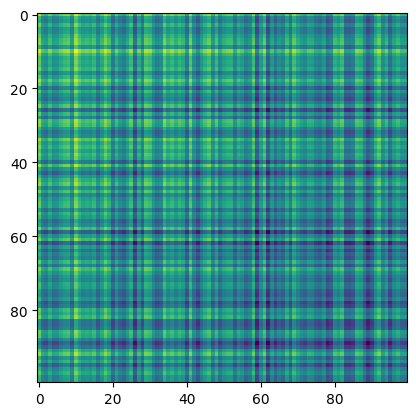

In [73]:
plt.imshow(torch.mean(outer_concat[0,:,:,:], dim=0).detach().numpy())

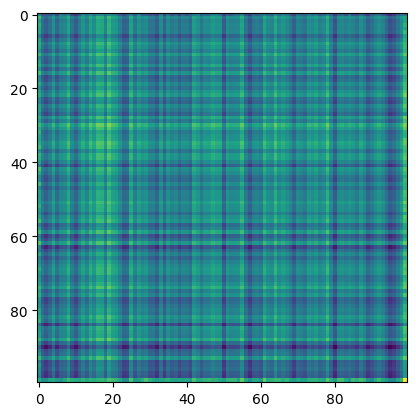

In [74]:
plt.imshow(torch.squeeze(torch.mean(output_conv2d,dim=1)).detach().numpy())

In [70]:
output_conv2d.shape

torch.Size([1, 32, 98, 98])

# copying code from rna-fm github repository

In [86]:
embeddings = embeddings.unsqueeze(0)
embeddings.shape

torch.Size([1, 100, 640])

In [87]:
batch_size, seqlen, hiddendim = embeddings.size()
print(batch_size, seqlen, hiddendim)

1 100 640


In [88]:
embed_in = hiddendim
embed_reduction = 128
embed_reduction_layer = nn.Linear(embed_in, embed_reduction)

In [89]:
embeddings = embed_reduction_layer(embeddings)
embeddings.shape

torch.Size([1, 100, 128])

In [90]:
hiddendim = embed_reduction

In [92]:
embeddings.shape

torch.Size([1, 100, 128])

In [93]:
embeddings = embeddings.unsqueeze(2).expand(batch_size, seqlen, seqlen, hiddendim)
embedding_T = embeddings.permute(0, 2, 1, 3)
pairwise_concat_embedding = torch.cat([embeddings, embedding_T], dim=3)
pairwise_concat_embedding = pairwise_concat_embedding.permute(0, 3, 1, 2)

In [94]:
pairwise_concat_embedding.shape

torch.Size([1, 256, 100, 100])

In [95]:
main_dim = 32

In [96]:
first_layer = nn.Conv2d(embed_reduction*2, main_dim, kernel_size=1)

In [14]:
class MyBasicResBlock(nn.Module):
    expansion: int = 1

    def __init__(
        self,
        inplanes: int,
        planes: int,
        stride: int = 1,
        groups: int = 1,
        dilation: int = 1,
        dropout: float = 0.3
    ) -> None:
        super(MyBasicResBlock, self).__init__()

        # Both self.conv1 and self.downsample layers downsample the input when stride != 1
        #self.bn1 = nn.BatchNorm2d(inplanes)
        self.norm1 = nn.LayerNorm(inplanes)
        self.relu1 = nn.ReLU(inplace=True)
        self.conv1 = nn.Conv2d(inplanes, planes, kernel_size=3, stride=stride,
                               padding=dilation, groups=groups, bias=False, dilation=dilation)
        self.dropout = nn.Dropout(p=dropout)
        self.relu2 = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(planes, planes, kernel_size=3, stride=stride,
                               padding=dilation, groups=groups, bias=False, dilation=dilation)

    def forward(self, x: torch.Tensor, mask: torch.Tensor = None) -> torch.Tensor:
        identity = x # (B, C, L, L)

        #out = self.bn1(x) # BatchNorm
        
        x = x.permute(0,2,3,1) # (B, L, L, C)
        out = self.norm1(x) # LayerNorm
        out = out.permute(0,3,1,2).contiguous() # (B, C, L, L)
        
        out = self.relu1(out)
        
        if mask is not None:
            out *= mask
        out = self.conv1(out)
        
        out = self.dropout(out)
        out = self.relu2(out)

        if mask is not None:
            out *= mask
        out = self.conv2(out)
        
        out += identity

        return out

In [111]:
main_dim = 32

In [112]:
num_res_layers = 32
res_layers = []
for i in range(num_res_layers):
    dilation = pow(2, (i % 3))
    res_layers.append(MyBasicResBlock(inplanes=main_dim, planes=main_dim, dilation=dilation))
res_layers = nn.Sequential(*res_layers)

final_layer = nn.Conv2d(main_dim, main_dim, kernel_size=3, padding=1)

In [106]:
layers = OrderedDict()
layers["first"] = first_layer
layers["resnet"] = res_layers
layers["final"] = final_layer
entire_resnet = nn.Sequential(layers)

In [109]:
features = entire_resnet(pairwise_concat_embedding)

In [111]:
features.shape

torch.Size([1, 32, 100, 100])

In [116]:
mean_pool = features.mean(dim=(-1,-2))
mean_pool.shape

torch.Size([1, 32])

In [118]:
max_pool = features.amax(dim=(-1,-2))
max_pool.shape

torch.Size([1, 32])

In [120]:
pooled = torch.cat([mean_pool, max_pool], dim=1)
pooled.shape

torch.Size([1, 64])

In [121]:
mlp_head_hidden = 64

mlp_head = nn.Sequential(nn.Linear(2*main_dim, mlp_head_hidden),
                         nn.ReLU(),
                         nn.Dropout(p=0.3),
                         nn.Linear(mlp_head_hidden, 1))

In [122]:
logit = mlp_head(pooled)

In [123]:
logit

tensor([[-0.3637]], grad_fn=<AddmmBackward0>)

In [128]:
torch.sigmoid(logit.squeeze())

tensor(0.4101, grad_fn=<SigmoidBackward0>)

# batch of sequences with padding and masking

In [6]:
handpicked_cols = ["gc_content", "mfe", "n_local_minima"]

In [7]:
data = prepare_data(DATA_PATH, n_bins=N_BINS, random_state=SEED, handpicked_cols=handpicked_cols, data_mask=data_mask)

In [8]:
train_loader = make_dataloader(data.train, batching='lengthbucket_padded', batch_size=32, shuffle=True, embedding_dict=embeddings_dict)

In [9]:
counter = 0

batch_sequences = torch.tensor([])
batch_structures = torch.tensor([])
batch_statics = torch.tensor([])
batch_targets = torch.tensor([])
batch_embeds = torch.tensor([])
batch_lengths = torch.tensor([])

for sequences, structures, statics, targets, embeds, lengths in train_loader:
    batch_sequences = sequences
    batch_structures = structures
    batch_statics = statics
    batch_targets = targets
    batch_embeds = embeds
    batch_lengths = lengths

    print(lengths)
    print(targets)
    counter += 1
    if counter == 1:
        break

tensor([20, 20, 24, 23, 26, 22, 22, 20, 24, 24, 26, 24, 29, 20, 24, 23, 20, 23,
        20, 28, 17, 17, 19, 29, 26, 25, 18, 22, 23, 26, 17, 19])
tensor([1., 0., 1., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0.])


In [10]:
class BaseModel(nn.Module):
    """Marker base class. Subclasses must set BATCHING and implement forward."""

    # "exact_length" -> requires uniform-length batches (no padding)
    # "padded"       -> handles variable-length / padded batches fine
    BATCHING = "padded"

    def forward(self, sequence, structure, static_features, embeddings,lengths=None):
        raise NotImplementedError

In [15]:
class PairwiseMapResNet(BaseModel):
    """
    RNA-FM embeddings -> pairwise map of embeddings (outer concatenation) -> ResNet32 -> concat mean and max Pool
    -> fully connected layer -> a single output logit to predict whether the folding time distribution has 1 peak or 2 peaks

    Up to ResNet32, the architecture is the same as what the RNA-FM paper (Chen et al 2022) used to predict RNA secondary structure
    Some code was heavily inspired / copied from the corresponding GitHub repo:
    https://github.com/ml4bio/RNA-FM/blob/main/fm/downstream/pairwise_predictor/pairwise_concat.py#L5
    """

    BATCHING = "lengthbucket_padded"

    def __init__(self, embedding_dim: int = 640, projection_dim: int = 128, resnet_dim: int = 32,
                 num_res_layers: int = 32, dropout: float = 0.3,
                 static_feature_size: int = 3, output_size: int = 50, mlp_hidden_size: int = 64):
        super().__init__()
        self.embedding_dim = embedding_dim
        self.projection_dim = projection_dim
        self.resnet_dim = resnet_dim

        # Step 1: project embeddings to a lower dimension
        self.input_proj = nn.Linear(embedding_dim, projection_dim)

        # Step 3: resnet
        self.first_layer = nn.Conv2d(2*projection_dim, resnet_dim, kernel_size=1)

        self.res_layers = nn.ModuleList()
        for i in range(num_res_layers):
            dilation = pow(2, (i % 3)) # 1,2,4,1,2,4,1,2,4,...
            self.res_layers.append(MyBasicResBlock(inplanes=resnet_dim, planes=resnet_dim,
                                              dilation=dilation, dropout=dropout))
        # res_layers = nn.Sequential(*res_layers)

        self.final_layer = nn.Conv2d(resnet_dim, resnet_dim, kernel_size=3, padding=1)

        # layers = OrderedDict()
        # layers["first"] = first_layer
        # layers["resnet"] = res_layers
        # layers["final"] = final_layer
        # self.resnet = nn.Sequential(layers)
        
        # Step 5: Late Fusion Prediction Head (MLP)
        mlp_input_size = 2*resnet_dim + static_feature_size
        self.mlp = nn.Sequential(
            nn.Linear(mlp_input_size, mlp_hidden_size),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(mlp_hidden_size, output_size),
        )
        
    def forward(self, sequence, structs, static_features, embeddings, lengths=None):
        if lengths is not None:
            mask_1d = torch.arange(torch.amax(lengths)).unsqueeze(0) < lengths.unsqueeze(1) # (batch_size, max_seq_length)
            mask_2d = torch.einsum('bi,bj->bij', mask_1d, mask_1d).unsqueeze(1).float() # (batch_size, 1, max_seq_length, max_seq_length)

        x = embeddings # (batch_size, max_seq_len, embedding_dim)

        # Step 1: project embeddings to a lower dimension
        x = self.input_proj(x)
        batch_size, max_seq_len, _ = x.shape # (batch_size, max_seq_len, projection_dim)

        # Step 2: pairwise concatenation
        x = x.unsqueeze(2).expand(batch_size, max_seq_len, max_seq_len, self.projection_dim)
        x_T = x.permute(0, 2, 1, 3)
        pairwise_concat = torch.cat([x, x_T], dim=3) # (batch_size, max_seq_len, max_seq_len, 2*projection_dim)
        pairwise_concat = pairwise_concat.permute(0, 3, 1, 2) # (batch_size, 2*projection_dim, max_seq_len, max_seq_len)

        # Step 3: resnet
        if lengths is not None:
            x_resnet = self.first_layer(pairwise_concat * mask_2d) # (batch_size, resnet_dim, max_seq_len, max_seq_len)
            for res_layer in self.res_layers:
                x_resnet = res_layer(x_resnet, mask_2d) # (batch_size, resnet_dim, max_seq_len, max_seq_len)
            x_resnet = self.final_layer(x_resnet * mask_2d) # (batch_size, resnet_dim, max_seq_len, max_seq_len)
        else:
            x_resnet = self.first_layer(pairwise_concat) # (batch_size, resnet_dim, seq_len, seq_len)
            for res_layer in self.res_layers:
                x_resnet = res_layer(x_resnet) # (batch_size, resnet_dim, seq_len, seq_len)
            x_resnet = self.final_layer(x_resnet) # (batch_size, resnet_dim, seq_len, seq_len)

        # Step 4: mean pool and max pool
        if lengths is not None:
            # Sum up valid positions and divide by sequence lengths for a clean mean-pool
            mean_pooled = (x_resnet * mask_2d).sum(dim=(2,3)) / lengths.unsqueeze(1).float()**2 # (batch_size, resnet_dim)

            # Set non-valid positions to negative infinity for a clean max-pool
            mask_2d_ninf = torch.zeros_like(mask_2d)
            mask_2d_ninf[mask_2d == 0] = -torch.inf
            max_pooled = (x_resnet + mask_2d_ninf).amax(dim=(2,3)) # (batch_size, resnet_dim)
        else:
            mean_pooled = x_resnet.mean(dim=(2,3)) # (batch_size, resnet_dim)
            max_pooled = x_resnet.amax(dim=(2,3)) # (batch_size, resnet_dim)
            
        # Step 5: Late Fusion with Tabular Static Features
        combined = torch.cat([mean_pooled, max_pooled, static_features], dim=-1) # (batch_size, 2*resnet_dim + static_feature_size)
        
        # Step 6: Map directly to output:
        # Either 50 logits for the folding time distribution prediction
        # or a single logit for 1 peak vs 2 peak classification
        return self.mlp(combined)

In [16]:
batch_embeds.shape

torch.Size([32, 29, 640])

In [24]:
test_resnet = PairwiseMapResNet(output_size=1, dropout=0.3)

In [25]:
test_resnet.eval()

PairwiseMapResNet(
  (input_proj): Linear(in_features=640, out_features=128, bias=True)
  (first_layer): Conv2d(256, 32, kernel_size=(1, 1), stride=(1, 1))
  (res_layers): ModuleList(
    (0): MyBasicResBlock(
      (norm1): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
      (relu1): ReLU(inplace=True)
      (conv1): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (dropout): Dropout(p=0.3, inplace=False)
      (relu2): ReLU(inplace=True)
      (conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    )
    (1): MyBasicResBlock(
      (norm1): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
      (relu1): ReLU(inplace=True)
      (conv1): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(2, 2), dilation=(2, 2), bias=False)
      (dropout): Dropout(p=0.3, inplace=False)
      (relu2): ReLU(inplace=True)
      (conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(2, 2), dilation=(2, 2)

In [26]:
logits = test_resnet.forward(batch_sequences, batch_structures, batch_statics, batch_embeds, batch_lengths)

In [27]:
logits_separate = []

for i in range(len(batch_lengths)):
    logit_i = test_resnet.forward(batch_sequences[i].unsqueeze(0), batch_structures[i].unsqueeze(0), batch_statics[i].unsqueeze(0), batch_embeds[i][:batch_lengths[i]].unsqueeze(0), None)
    logit_i = logit_i.squeeze()
    logits_separate.append(logit_i)

logits_separate = torch.tensor(logits_separate)

In [28]:
logits.squeeze()

tensor([-0.1160, -0.1923, -0.1824, -0.1305, -0.1554, -0.1315, -0.0888, -0.1724,
        -0.1349, -0.1271, -0.1508, -0.1514, -0.1307, -0.0957, -0.1206, -0.1413,
        -0.1214, -0.1246, -0.1858, -0.1524, -0.1830, -0.1505, -0.0866, -0.1554,
        -0.1235, -0.0568, -0.1221, -0.1801, -0.1186, -0.1459, -0.1666, -0.1691],
       grad_fn=<SqueezeBackward0>)

In [29]:
logits_separate

tensor([-0.1160, -0.1923, -0.1824, -0.1305, -0.1554, -0.1315, -0.0888, -0.1724,
        -0.1349, -0.1271, -0.1508, -0.1514, -0.1307, -0.0957, -0.1206, -0.1413,
        -0.1214, -0.1246, -0.1858, -0.1524, -0.1830, -0.1505, -0.0866, -0.1554,
        -0.1235, -0.0568, -0.1221, -0.1801, -0.1186, -0.1459, -0.1666, -0.1691])

In [30]:
logits_separate - logits.squeeze()

tensor([ 4.4703e-08,  5.9605e-08,  1.1921e-07, -7.4506e-08,  1.4901e-08,
        -2.9802e-08, -1.3411e-07,  2.9802e-08,  0.0000e+00,  1.1921e-07,
        -2.9802e-08, -5.9605e-08,  0.0000e+00, -5.9605e-08, -4.4703e-08,
        -1.0431e-07, -1.6391e-07, -1.4901e-08,  8.9407e-08,  1.4901e-08,
         2.9802e-08,  0.0000e+00,  7.4506e-08, -1.4901e-08,  0.0000e+00,
         4.4703e-08, -8.9407e-08, -1.1921e-07, -2.9802e-08,  0.0000e+00,
         2.9802e-08, -8.9407e-08], grad_fn=<SubBackward0>)

## 2d mask

In [113]:
mask = torch.arange(torch.amax(batch_lengths)).unsqueeze(0) < batch_lengths.unsqueeze(1)

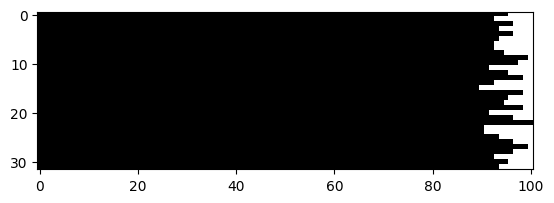

In [114]:
plt.imshow(mask, cmap="Grays")

In [115]:
mask.shape

torch.Size([32, 101])

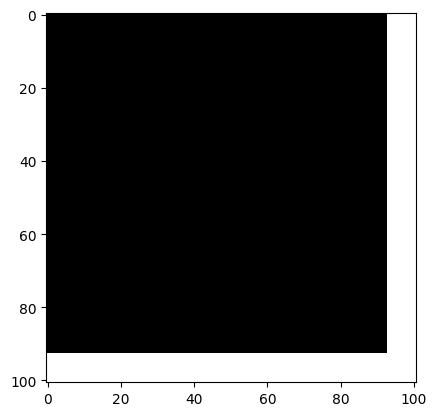

In [117]:
plt.imshow(torch.outer(mask[1], mask[1]), cmap='Grays')

In [118]:
mask_2d = torch.einsum('bi,bj->bij', mask, mask)

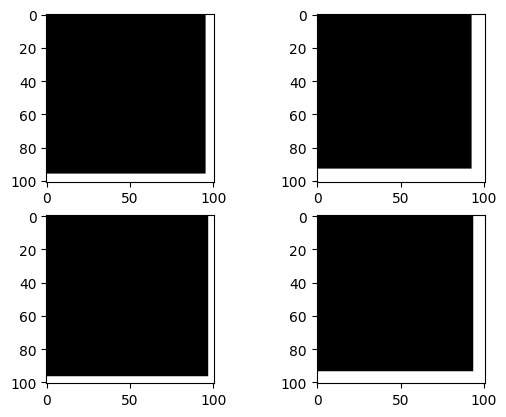

In [119]:
fig, axs = plt.subplots(2,2)

for ix in range(2):
    for iy in range(2):
        axs[ix,iy].imshow(mask_2d[2*ix+iy], cmap='Grays')

## pairwise concat + resnet

In [73]:
x = batch_embeds

In [74]:
x.shape

torch.Size([32, 101, 640])

In [75]:
input_proj = nn.Linear(640, 128)

In [76]:
x = input_proj(x)

In [79]:
batch_size, max_seq_len, hidden_dim = x.shape
print(batch_size, max_seq_len, hidden_dim)

32 101 128


In [80]:
x = x.unsqueeze(2).expand(batch_size, max_seq_len, max_seq_len, hidden_dim)

In [81]:
x.shape

torch.Size([32, 101, 101, 128])

In [82]:
x_T = x.permute(0, 2, 1, 3)

In [83]:
pairwise_concat = torch.cat([x, x_T], dim=3)

In [84]:
pairwise_concat.shape

torch.Size([32, 101, 101, 256])

In [85]:
pairwise_concat = pairwise_concat.permute(0, 3, 1, 2)

In [86]:
pairwise_concat.shape

torch.Size([32, 256, 101, 101])

In [96]:
projection_dim = 128
resnet_dim = 32
dropout = 0.3
num_res_layers = 4

In [ ]:
first_layer = nn.Conv2d(2*projection_dim, resnet_dim, kernel_size=1)

res_layers = []
for i in range(num_res_layers):
    dilation = pow(2, (i % 3)) # 1,2,4,1,2,4,1,2,4,...
    res_layers.append(MyBasicResBlock(inplanes=resnet_dim, planes=resnet_dim,
                                      dilation=dilation, dropout=dropout))
res_layers = nn.Sequential(*res_layers)

final_layer = nn.Conv2d(resnet_dim, resnet_dim, kernel_size=3, padding=1)

layers = OrderedDict()
layers["first"] = first_layer
layers["resnet"] = res_layers
layers["final"] = final_layer
resnet = nn.Sequential(layers)

## mean pool and max pool, using masking to correct for padding

In [98]:
features = resnet(pairwise_concat)

In [100]:
features.shape

torch.Size([32, 32, 101, 101])

In [122]:
mask_2d.unsqueeze(1).shape

torch.Size([32, 1, 101, 101])

In [123]:
(features * mask_2d.unsqueeze(1)).shape

torch.Size([32, 32, 101, 101])

In [124]:
masked_features = features * mask_2d.unsqueeze(1)

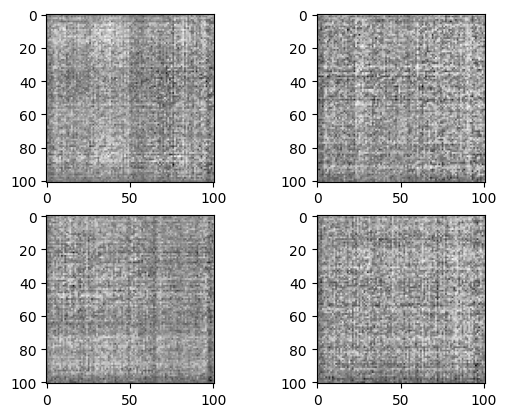

In [127]:
fig, axs = plt.subplots(2,2)

for ix in range(2):
    for iy in range(2):
        axs[ix,iy].imshow(features.detach().numpy()[2*ix+iy,0,:,:], cmap='Grays')

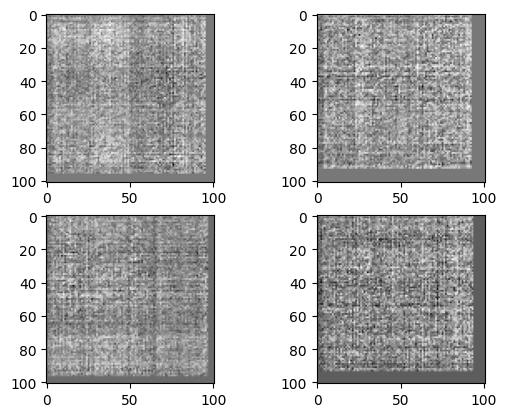

In [126]:
fig, axs = plt.subplots(2,2)

for ix in range(2):
    for iy in range(2):
        axs[ix,iy].imshow(masked_features.detach().numpy()[2*ix+iy,0,:,:], cmap='Grays')

In [129]:
masked_features.shape

torch.Size([32, 32, 101, 101])

In [ ]:
torch.sum(features * mask_2d.unsqueeze(1), dim=(-1,-2)).shape

torch.Size([32, 32])

In [133]:
torch.sum(mask_2d.unsqueeze(1), dim=(-1,-2)).shape

torch.Size([32, 1])

In [136]:
torch.sum(mask_2d.unsqueeze(1), dim=(-1,-2)).squeeze()

tensor([ 9216,  8649,  9409,  8836,  9409,  8836,  8649,  8649,  9025, 10000,
         9604,  8464,  9216,  9801,  8649,  8100,  9801,  9216,  9025,  9801,
         8464,  9409, 10201,  8281,  8281,  8836,  9409, 10000,  9409,  8649,
         9216,  8836])

In [138]:
batch_lengths**2

tensor([ 9216,  8649,  9409,  8836,  9409,  8836,  8649,  8649,  9025, 10000,
         9604,  8464,  9216,  9801,  8649,  8100,  9801,  9216,  9025,  9801,
         8464,  9409, 10201,  8281,  8281,  8836,  9409, 10000,  9409,  8649,
         9216,  8836])

In [ ]:
mean_pool = torch.sum(features * mask_2d.unsqueeze(1), dim=(-1,-2)) / torch.sum(mask_2d.unsqueeze(1), dim=(-1,-2))
mean_pool.shape

torch.Size([32, 32])

In [ ]:
torch.amin(torch.tensor([1,2,3]))

tensor(1)

In [146]:
max_pool = torch.amax(features * mask_2d.unsqueeze(1), dim=(-1,-2))
max_pool.shape

torch.Size([32, 32])

In [148]:
np.any((max_pool == 0).detach().numpy())

np.False_

In [149]:
pooled = torch.cat([mean_pool, max_pool], dim=1)
pooled.shape

torch.Size([32, 64])

In [150]:
x_resnet = features

In [152]:
batch_lengths

tensor([ 96,  93,  97,  94,  97,  94,  93,  93,  95, 100,  98,  92,  96,  99,
         93,  90,  99,  96,  95,  99,  92,  97, 101,  91,  91,  94,  97, 100,
         97,  93,  96,  94])

In [ ]:
mask_1d = torch.arange(torch.amax(batch_lengths)).unsqueeze(0) < batch_lengths.unsqueeze(1) # (batch_size, max_seq_length)
mask_2d = torch.einsum('bi,bj->bij', mask_1d, mask_1d).unsqueeze(1).float() # (batch_size, 1, max_seq_length, max_seq_length)
# Sum up valid positions and divide by sequence lengths for a clean mean-pool
mean_pooled = (x_resnet * mask_2d).sum(dim=(2,3)) / batch_lengths.unsqueeze(1).float()**2

In [183]:
batch_lengths.unsqueeze(-1).shape

torch.Size([32, 1])

In [184]:
mean_pooled.shape

torch.Size([32, 32])

In [168]:
-100000 > -torch.inf

True

In [ ]:
mask_2d_ninf = torch.zeros_like(mask_2d)
mask_2d_ninf[mask_2d == 0] = -torch.inf

In [188]:
mask_2d

tensor([[[[1., 1., 1.,  ..., 0., 0., 0.],
          [1., 1., 1.,  ..., 0., 0., 0.],
          [1., 1., 1.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]]],


        [[[1., 1., 1.,  ..., 0., 0., 0.],
          [1., 1., 1.,  ..., 0., 0., 0.],
          [1., 1., 1.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]]],


        [[[1., 1., 1.,  ..., 0., 0., 0.],
          [1., 1., 1.,  ..., 0., 0., 0.],
          [1., 1., 1.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]]],


        ...,


        [[[1., 1., 1.,  ..., 0., 0., 0.],
          [1., 1., 1.,  ..., 0., 0., 0.],
          [1., 1., 1.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0.

In [189]:
mask_2d_ninf

tensor([[[[0., 0., 0.,  ..., -inf, -inf, -inf],
          [0., 0., 0.,  ..., -inf, -inf, -inf],
          [0., 0., 0.,  ..., -inf, -inf, -inf],
          ...,
          [-inf, -inf, -inf,  ..., -inf, -inf, -inf],
          [-inf, -inf, -inf,  ..., -inf, -inf, -inf],
          [-inf, -inf, -inf,  ..., -inf, -inf, -inf]]],


        [[[0., 0., 0.,  ..., -inf, -inf, -inf],
          [0., 0., 0.,  ..., -inf, -inf, -inf],
          [0., 0., 0.,  ..., -inf, -inf, -inf],
          ...,
          [-inf, -inf, -inf,  ..., -inf, -inf, -inf],
          [-inf, -inf, -inf,  ..., -inf, -inf, -inf],
          [-inf, -inf, -inf,  ..., -inf, -inf, -inf]]],


        [[[0., 0., 0.,  ..., -inf, -inf, -inf],
          [0., 0., 0.,  ..., -inf, -inf, -inf],
          [0., 0., 0.,  ..., -inf, -inf, -inf],
          ...,
          [-inf, -inf, -inf,  ..., -inf, -inf, -inf],
          [-inf, -inf, -inf,  ..., -inf, -inf, -inf],
          [-inf, -inf, -inf,  ..., -inf, -inf, -inf]]],


        ...,


        [[

In [194]:
max_pooled = (x_resnet + mask_2d_ninf).amax(dim=(2,3))

In [196]:
torch.equal(max_pooled, max_pool)

True